# Supplementary Material 1.1 (S1.1): PDE-Weight Comparison

This notebook reproduces the S1.1 plots for the supplementary PDE-weight comparison.

The notebook contains:

1. A `pde_weight` $\lambda_{\text{PDE}} \in \{1, 2, 10, 100\}$ at fixed architecture `(W_D, W_u) = (2, 64)` across $ES \in \{1000, 2000\}$.
2. Diffusion-function comparisons for models from that sweep.
3. Smoothed loss-component and density-error comparisons across the same `pde_weight` grid.

*It produces Fig. S1 in the supplementary material.*


In [1]:
import os
import sys
from pathlib import Path

import numpy as np

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_data import build_catalog, load_data_object
from Training.JN.notebook_helpers.notebook_config import (
    BCbool,
    BNdataLossFuncLabel,
    D_one_param_bool,
    binn_batch_size,
    binn_lr,
    binn_model_num,
    binn_rel_save_thresh,
    binn_rel_update_thresh,
    binnDevice,
    binnGenerateIndicesLabel,
    binnVF,
)
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    filter_model_catalog,
    load_requested_models,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

PATHS = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = PATHS.project_root
TRAINING_ROOT = PATHS.training_root
JN_ROOT = PATHS.notebook_root
DATA_ROOT = PATHS.data_root
BINN_ROOT = PATHS.binn_root

register_notebook_pickle_globals()

from paper_helpers import (
    dictToPath,
    plot_diffusion_across_epochs,
    plot_running_min_MSE_diff_loss_broken_x_log_lst,
    plot_running_min_loss_component_broken_x_log_lst,
    plot_smoothed_loss_components_seed_broken_x_log_lst,
    plot_binned_density_error_agg_groups_multi_data_mean
)





## 1. Load the S1.1 data

We first recover the simulated reaction-diffusion dataset used throughout the notebook. The cell below verifies that the S1.1 data object exists on disk before any model analysis begins. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462)

In [2]:
# Shared data-object catalogue used by this notebook.
data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")

REALISTIC_CARRYING_CAPACITY = 1700 # cells/mm^2
DATA_GAMMA = 1
DATA_NOISE_PERCENT = 1
DATA_X2_NUM = 1

S11_DATA_CONFIG = {
    "dataX1num": 38,
    "dataX2num": DATA_X2_NUM,
    "dataTnum": 5,
    "dataK": 1,
    "dataICLabel": "cos",
    "dataDiffLabel": "const",
    "dataGrowLabel": "zero",
    "dataGamma": DATA_GAMMA,
    "dataNoisePercent": DATA_NOISE_PERCENT,
    "dataNoiseSeed": 0,
}

data_obj, _ = load_data_object(
    S11_DATA_CONFIG,
    DATA_ROOT,
    data_df=data_df,
)


## 2. Build the S1.1 model catalogue & form helper functions for model loading and plotting


### 2.1. Catalogue trained model

Next we catalogue all saved BINN checkpoints under `Training/binn`, filter them to the fixed assumptions used in S1.1, and build the helper state needed for the figure sweeps below.

The varying dimensions in this notebook are `pde_weight`, `binnES`, and `binnTVsplitSeed`; the architecture is otherwise held fixed for S1.1.

In [3]:
# Catalogue of all saved BINN checkpoints across the training study.
binn_df = build_model_catalog(BINN_ROOT)

S11_NUM_PDE_SAMPLES = 1000

ALL_CONSTRAINTS = True
CONSTRAINT_TUPLE = (True, True, False, False)
CONSTRAINT_WEIGHTS = {
    "D_bound_weight": 0,
    "D_mono_weight": 1e1,
}
CONSTRAINT_BOUNDS = {
    "D_bound": (0, 0.1),
}
FIXED_G_WIDTH = None

S11_SHARED_MODEL_FILTERS = {
    "binnVF": binnVF,
    "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
    "DoneParamBool": D_one_param_bool,
    "binnDevice": binnDevice,
    "allConstraints": ALL_CONSTRAINTS,
    "BCbool": BCbool,
    "numPDEsamples": S11_NUM_PDE_SAMPLES,
    "binnLR": binn_lr,
    "binnBatchSize": binn_batch_size,
    "binnRelUpdateThresh": binn_rel_update_thresh,
    "binnRelSaveThresh": binn_rel_save_thresh,
    "BNdataLossFuncLabel": BNdataLossFuncLabel,
}
if ALL_CONSTRAINTS:
    S11_SHARED_MODEL_FILTERS |= active_constraint_settings(
        CONSTRAINT_TUPLE,
        CONSTRAINT_WEIGHTS,
        CONSTRAINT_BOUNDS,
    )

S11_FIXED_FILTERS = S11_DATA_CONFIG | S11_SHARED_MODEL_FILTERS | {
    "binnGsize": FIXED_G_WIDTH,
}

s11_catalog = filter_model_catalog(
    binn_df,
    S11_FIXED_FILTERS,
    empty_message="No BINN models were found for the fixed S1.1 assumptions in this notebook.",
)


### 2.2 Shared plotting style

These settings define the common colour palettes, plotting helpers, and reference metrics reused across the S1.1 results plots.

In [5]:
BLUE_COLORS = [
    "#0033A0",
    "#1E90FF",
    "#6699CC",
    "#A4C8E1",
    "#D6EAF8",
]

D_COLORS = [
    "#8B2500",
    "#FF7F0E",
    "#FDB863",
    "#FDD9B5",
    "#FFF1E0",
]

G_COLORS = [
    "#00441B",
    "#1A9850",
    "#66C2A4",
    "#B2E2E2",
    "#E5F5F9",
]

PURPLE_COLORS = [
    "#c7c8e1",
    "#999fcb",
    "#7b80bc",
    "#4a3298",
][::-1]

PINK_COLORS = [
    "#fbafba",
    "#f57094",
    "#e73c7e",
    "#9b0079",
][::-1]

LINESTYLES = ["-"] * 5
MARKER_STYLES = ["o"] * 5
FIGSIZE = (7, 5)
MAX_EPOCH = 9e3
BREAK_EPOCH_SHORT = 2e2
MIN_EPOCH = 0
X_AXIS = {"min": MIN_EPOCH, "max": MAX_EPOCH, "break": BREAK_EPOCH_SHORT}
LEGEND_SIZE = 18
DIFF_MIN = 3e-7
AXIS_FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 18,
    "yaxis": 18,
    "ytick_labels": 18,
}

def plot_params_from_models(models_dics, colors):
    model_keys = list(models_dics.keys())
    return {
        key: [colors[i], LINESTYLES[i], MARKER_STYLES[i], str(key)]
        for i, key in enumerate(model_keys)
    }





### 2.3. Helpers functions for loading trained models

These helpers resolve the trained `pde_weight` checkpoints from the catalogue and load them into the nested dictionaries used by the figure sweeps.

In [6]:
S11_DIFF_LABEL = "const"
S11_GROWTH_LABEL = "zero"
S11_U_WIDTHS = [64]
S11_D_WIDTHS = [2]
SELECTED_D_WIDTH = 2
S11_ES_VALUES = [1000, 2000]
SELECTED_ES = S11_ES_VALUES[-1]
S11_SPLIT_SEEDS = [0, 1, 2]
PDE_WEIGHTS = [1e0, 2e0, 1e1, 1e2]
SELECTED_PDE_WEIGHT = PDE_WEIGHTS[0]
SELECTED_U_WIDTH = S11_U_WIDTHS[0]
PATH_DEBUG = False

if PATH_DEBUG:
    print(
        "Active PDE-weight config:",
        {
            "diff_label": S11_DIFF_LABEL,
            "growth_label": S11_GROWTH_LABEL,
            "gamma": DATA_GAMMA,
            "noise_percent": DATA_NOISE_PERCENT,
            "dataX2num": DATA_X2_NUM,
            "numPDEsamples": S11_NUM_PDE_SAMPLES,
        },
    )

weighted_placeholder_dict = None
unweighted_placeholder_dict = None

for _path_dict in s11_catalog["path_dict"]:
    _path_dict = dict(_path_dict)
    _has_loss_weights = any(
        key in _path_dict for key in ("surface_weight", "pde_weight")
    )
    if _has_loss_weights and weighted_placeholder_dict is None:
        weighted_placeholder_dict = _path_dict
    if not _has_loss_weights and unweighted_placeholder_dict is None:
        unweighted_placeholder_dict = _path_dict

if weighted_placeholder_dict is None:
    weighted_placeholder_dict = dict(s11_catalog["path_dict"].iloc[0])

if unweighted_placeholder_dict is None:
    unweighted_placeholder_dict = {
        k: v
        for k, v in weighted_placeholder_dict.items()
        if k not in {"surface_weight", "pde_weight"}
    }


def insert_loss_weight_params(path_dict, surface_weight, pde_weight):
    weighted_dict = {}
    inserted = False
    for key, value in path_dict.items():
        if key == "BNdataLossFuncLabel" and not inserted:
            weighted_dict["surface_weight"] = surface_weight
            weighted_dict["pde_weight"] = pde_weight
            inserted = True
        if key not in {"surface_weight", "pde_weight"}:
            weighted_dict[key] = value
    if not inserted:
        weighted_dict["surface_weight"] = surface_weight
        weighted_dict["pde_weight"] = pde_weight
    return weighted_dict


def build_s11_binn_info(d_width, u_width, split_seed, binn_es, pde_weight=None):
    selected_pde_weight = SELECTED_PDE_WEIGHT if pde_weight is None else pde_weight

    if selected_pde_weight == 1e0:
        binn_info = dict(unweighted_placeholder_dict)
    else:
        binn_info = insert_loss_weight_params(
            weighted_placeholder_dict,
            surface_weight=1e0,
            pde_weight=selected_pde_weight,
        )

    binn_info["binnTVsplitSeed"] = split_seed
    binn_info["binnUsize"] = u_width
    binn_info["binnDsize"] = d_width
    binn_info["binnGsize"] = FIXED_G_WIDTH
    binn_info["binnES"] = binn_es
    binn_info["BNdataLossFuncLabel"] = BNdataLossFuncLabel
    binn_info["binnModelLabel"] = binn_model_num
    binn_info["numPDEsamples"] = S11_NUM_PDE_SAMPLES
    return binn_info


def load_s11_models(es_values, d_widths, u_widths, split_seeds, pde_weight=None):
    requested_models = [
        {
            "binnES": binn_es,
            "binnDsize": d_width,
            "binnUsize": u_width,
            "binnTVsplitSeed": split_seed,
            "path": BINN_ROOT / dictToPath(
                build_s11_binn_info(
                    d_width,
                    u_width,
                    split_seed,
                    binn_es,
                    pde_weight=pde_weight,
                )
            ) / f"binnModel{binn_model_num}.pth",
        }
        for binn_es in es_values
        for d_width in d_widths
        for u_width in u_widths
        for split_seed in split_seeds
    ]
    return load_requested_models(
        requested_models,
        device=binnDevice,
        group_keys=("binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"),
    )


s11_models_by_pde_weight = {
    pde_weight: load_s11_models(
        es_values=S11_ES_VALUES,
        d_widths=S11_D_WIDTHS,
        u_widths=S11_U_WIDTHS,
        split_seeds=S11_SPLIT_SEEDS,
        pde_weight=pde_weight,
    )
    for pde_weight in PDE_WEIGHTS
}
selected_pde_weight_models_by_es = s11_models_by_pde_weight[SELECTED_PDE_WEIGHT]

if not selected_pde_weight_models_by_es:
    raise FileNotFoundError("No loadable constant-diffusion, zero-growth BINN checkpoints were found.")

models_by_pde_weight_for_selected_arch = {
    pde_weight: s11_models_by_pde_weight[pde_weight][SELECTED_ES][SELECTED_D_WIDTH][SELECTED_U_WIDTH]
    for pde_weight in PDE_WEIGHTS
}


selected_es_models = selected_pde_weight_models_by_es[S11_ES_VALUES[0]]
selected_d_width_models = selected_es_models[SELECTED_D_WIDTH]
primary_plot_params = plot_params_from_models(
    selected_d_width_models,
    BLUE_COLORS,
)


pde_weight_diff_plot_params = plot_params_from_models(
    models_by_pde_weight_for_selected_arch,
    D_COLORS,
)

pde_weight_u_plot_params = plot_params_from_models(
    models_by_pde_weight_for_selected_arch,
    BLUE_COLORS,
)

# Output directory for the S1.1 figures.

figure_s1_dir = (
    JN_ROOT / "pngs" / "1D" / "case1" /"figS1"
)
os.makedirs(figure_s1_dir, exist_ok=True)


## 3. Sweep A: vary `pde_weight` at fixed `(W_D, W_u) = (2, 64)`

This section reproduces the supplementary PDE-weight sweep


SORTED ['1.0', '2.0', '10.0', '100.0']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_a.png


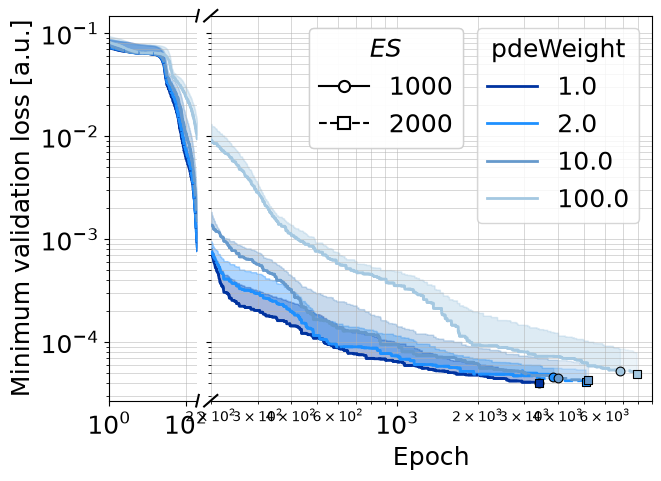

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_b.png


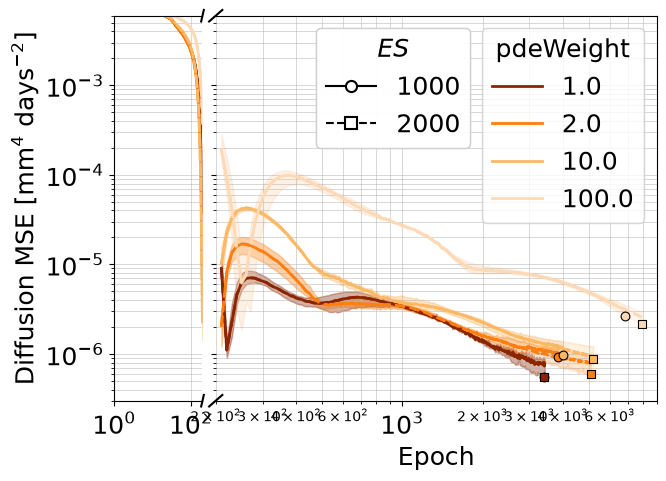

Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_0_diffusion_group_1_model0_ylim_0p015_0p11.png


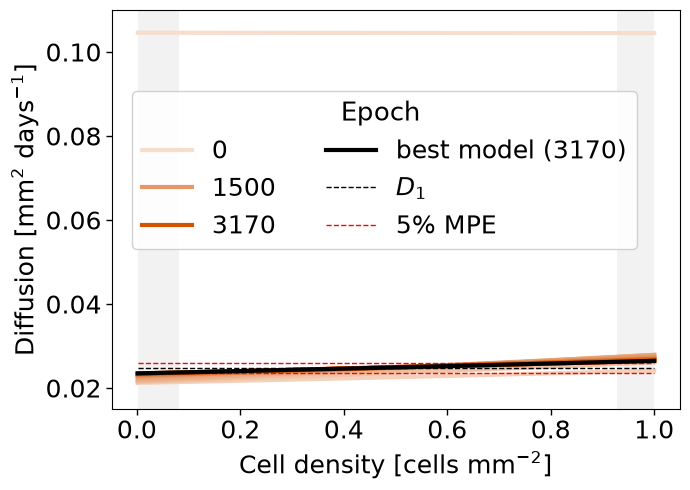

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_0_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_0_diffusion_group_1_model0_ylim_0p0234_0p026.png


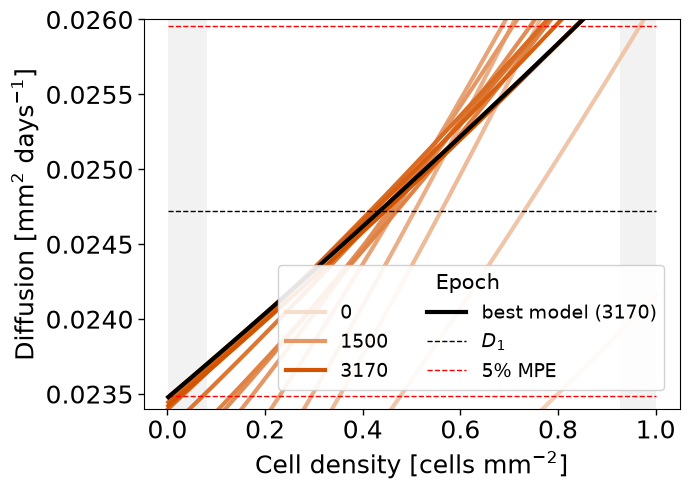

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_0_diffusion_group_1_model0_ylim_0p0234_0p026.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_1_diffusion_group_1_model0_ylim_0p015_0p11.png


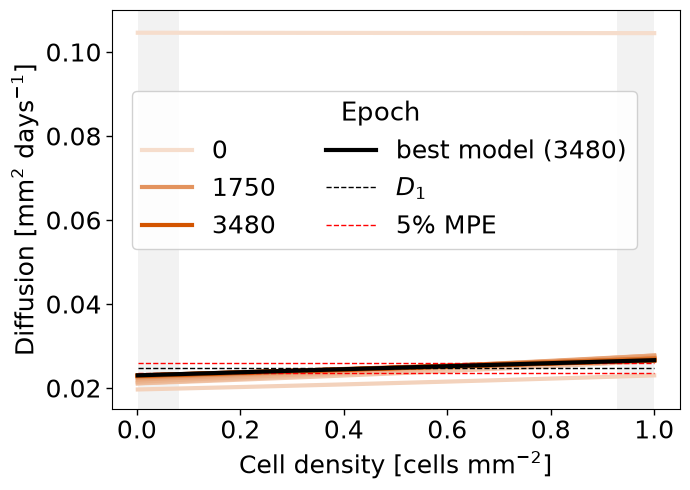

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_1_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_1_diffusion_group_1_model0_ylim_0p0234_0p026.png


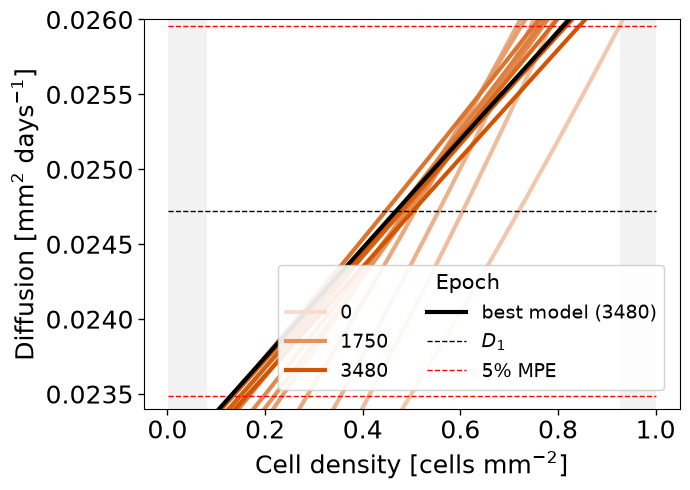

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_1_diffusion_group_1_model0_ylim_0p0234_0p026.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_2_diffusion_group_1_model0_ylim_0p015_0p11.png


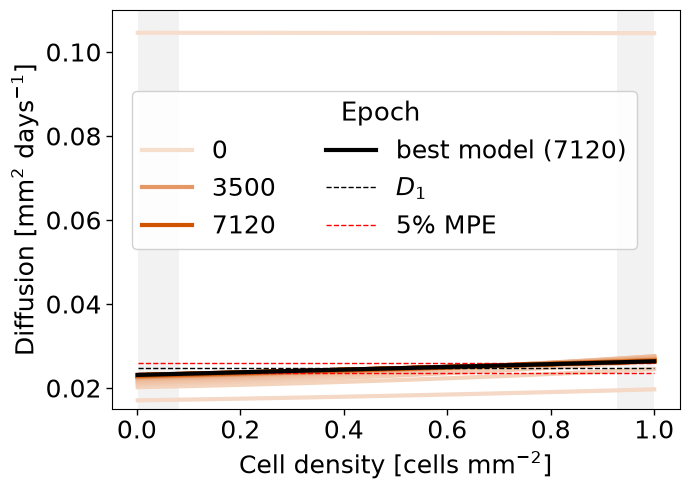

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_2_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_2_diffusion_group_1_model0_ylim_0p0234_0p026.png


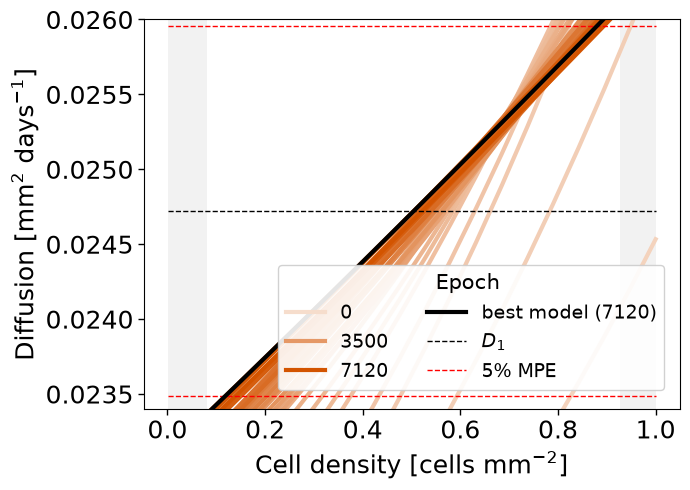

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_2_diffusion_group_1_model0_ylim_0p0234_0p026.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_3_diffusion_group_1_model0_ylim_0p015_0p11.png


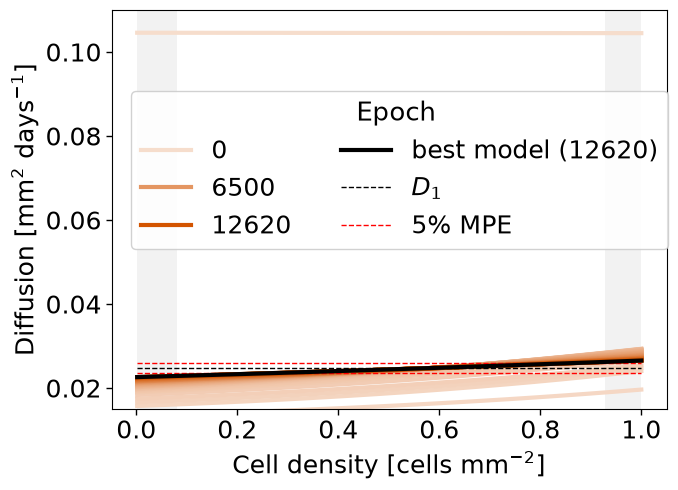

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_3_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_3_diffusion_group_1_model0_ylim_0p0234_0p026.png


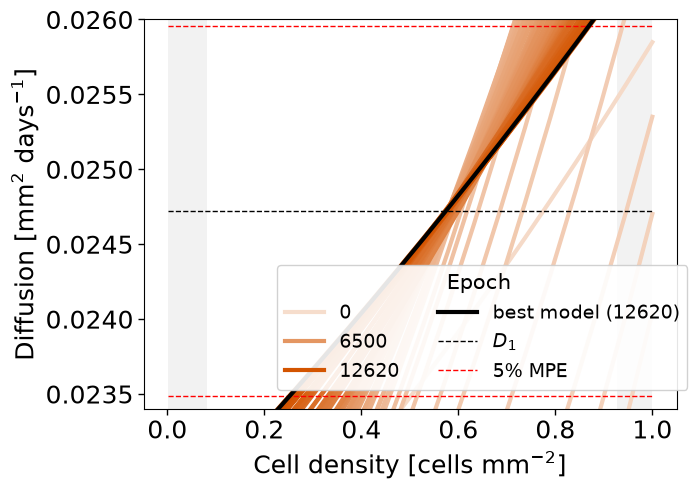

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_RHS_3_diffusion_group_1_model0_ylim_0p0234_0p026.png


In [7]:
if len(PDE_WEIGHTS) > 4:
    raise ValueError(
        "This plotting cell supports at most 4 pde_weight values. "
        f"Received {len(PDE_WEIGHTS)}: {PDE_WEIGHTS}"
    )


def select_weight_colors(color_list, n_values):
    if n_values <= 0:
        return []
    if n_values == 1:
        return [color_list[len(color_list) // 2]]
    color_idx = np.linspace(0, len(color_list) - 1, n_values, dtype=int).tolist()
    return [color_list[i] for i in color_idx]


pde_weight_purple_colors = select_weight_colors(
    PURPLE_COLORS,
    len(PDE_WEIGHTS),
)
pde_weight_pink_colors = select_weight_colors(
    PINK_COLORS,
    len(PDE_WEIGHTS),
)
pde_weight_d_color_by_value = {
    weight: pde_weight_pink_colors[i]
    for i, weight in enumerate(PDE_WEIGHTS)
}

models_by_es_for_selected_arch = [
    {
        weight: s11_models_by_pde_weight[weight][binn_es][SELECTED_D_WIDTH][SELECTED_U_WIDTH]
        for weight in PDE_WEIGHTS
    }
    for binn_es in S11_ES_VALUES
]

pde_weight_es_entries = [
    (str(binn_es), marker)
    for binn_es, marker in zip(S11_ES_VALUES, ["o", "s", "D", "^", "v", "P"])
]
validation_loss_plot_settings = {
    "name": str(figure_s1_dir / "plot_a.png"),
    "fill": True,
    "line_width": 2,
    "colors": pde_weight_purple_colors,
    "legend": {
        "panel": 2,
        "loc": (1, 1),
        "loc_upd": (0.6, 1),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
        "title": "pdeWeight",
        "marker_title": r"$ES$",
    },
    "xaxis": X_AXIS,
    "fontsizes": AXIS_FONTSIZES,
    "figsize": FIGSIZE,
    "es_entries": pde_weight_es_entries,
    "ylabel": "Minimum validation loss [a.u.]",
}

# Plot (a) of figure S1
plot_running_min_loss_component_broken_x_log_lst(
    models_dics_list=models_by_es_for_selected_arch,
    plot_params=pde_weight_u_plot_params,
    plot_settings=validation_loss_plot_settings,
    loss_attr="val_loss_list",
)

diffusion_mse_plot_settings = {
    "name": str(figure_s1_dir / "plot_b.png"),
    "fill": True,
    "line_width": 2,
    "colors": pde_weight_pink_colors,
    "legend": {
        "panel": 2,
        "loc": (0.575, 1),
        "loc_upd": (0.2, 1),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
        "title": "pdeWeight",
        "marker_title": r"$ES$",
    },
    "xaxis": X_AXIS,
    "fontsizes": AXIS_FONTSIZES,
    "figsize": FIGSIZE,
    "ylim": (DIFF_MIN, 0.6e-2),
    "es_entries": pde_weight_es_entries,
}

# Plot (b) of figure S1
plot_running_min_MSE_diff_loss_broken_x_log_lst(
    models_dics_list=models_by_es_for_selected_arch,
    plot_params=pde_weight_diff_plot_params,
    plot_settings=diffusion_mse_plot_settings,
)

plotted_pde_weights = list(PDE_WEIGHTS)
component_palette_indices = [
    PDE_WEIGHTS.index(weight)
    for weight in plotted_pde_weights
]
component_purple_colors = [
    pde_weight_purple_colors[i] for i in component_palette_indices
]
component_pink_colors = [
    pde_weight_pink_colors[i] for i in component_palette_indices
]

component_models_flat = [
    s11_models_by_pde_weight[weight][binn_es][SELECTED_D_WIDTH][SELECTED_U_WIDTH]
    for binn_es in S11_ES_VALUES
    for weight in plotted_pde_weights
]
component_color_indices = [
    weight_idx
    for _ in S11_ES_VALUES
    for weight_idx, _ in enumerate(plotted_pde_weights)
]
component_marker_indices = [
    es_idx
    for es_idx, _ in enumerate(S11_ES_VALUES)
    for _ in plotted_pde_weights
]
component_group_labels = [
    str(weight)
    for _ in S11_ES_VALUES
    for weight in plotted_pde_weights
]

COMPONENT_SEED = 0
COMPONENT_SMOOTHING_WINDOW = 25

component_smoothed_plot_settings = {
    "name": str(figure_s1_dir / "figS2_LHS"),
    "fill": True,
    "line_width": 2,
    "colors": component_purple_colors,
    "color_indices": component_color_indices,
    "marker_indices": component_marker_indices,
    "es_entries": pde_weight_es_entries,
    "xaxis": X_AXIS,
    "fontsizes": AXIS_FONTSIZES,
    "figsize": FIGSIZE,
    "ylabel": "Smoothed loss component [a.u]",
    "legend": {
        "panel": 2,
        "loc": (0.41, 1),
        "loc_upd": (0.8, 1),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
        "title": "Loss",
        "marker_title": "$ES$",
    },
}


# Plot (f)--(i) of figure S1
for i, pde_weight in enumerate(PDE_WEIGHTS):
    selected_d_width_models_for_pde_weight = s11_models_by_pde_weight[pde_weight][SELECTED_ES][SELECTED_D_WIDTH]

    diffusion_plot_settings = {
        "name": str(figure_s1_dir / f"plot_RHS_{i}.png"),
        "fill": True,
        "line_width": 2,
        "colors": [pde_weight_d_color_by_value[pde_weight]],
        "legends": [
            {
                "loc": (0.035, 0.4),
                "fontsize": LEGEND_SIZE,
                "ncols": 2,
                "framealpha": 0.9,
            },
            {
                "loc": (0.25, 0.05),
                "fontsize": 14,
                "ncols":2,
                "framealpha": 0.9,
            },
        ],
        "xaxis": X_AXIS,
        "fontsizes": AXIS_FONTSIZES,
        "figsize": FIGSIZE,
        "y_lims": [(0.015, 0.11), (0.0234, 0.026)],
        "mpe": 5,
        "epoch_step": 25,
        "epoch_sf": 10,
        "D_true_label": r"$D_1$",
    }

    plot_diffusion_across_epochs(
        overwrite=True,
        models_dics_list=[selected_d_width_models_for_pde_weight[S11_U_WIDTHS[0]]],
        plot_params=primary_plot_params,
        plot_settings=diffusion_plot_settings,
        seed_index=2,
        shade_outside_central_90=True,
    )



/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_components.py:673: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=xaxis["min"], right=xaxis["break"])
/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_components.py:1456: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_c.png


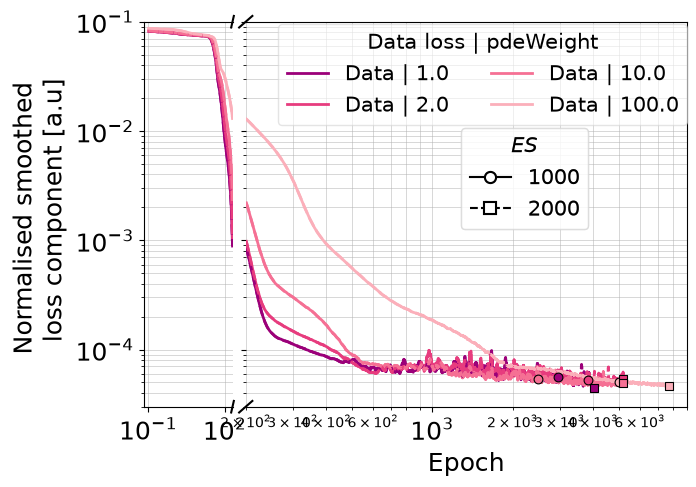

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_d.png


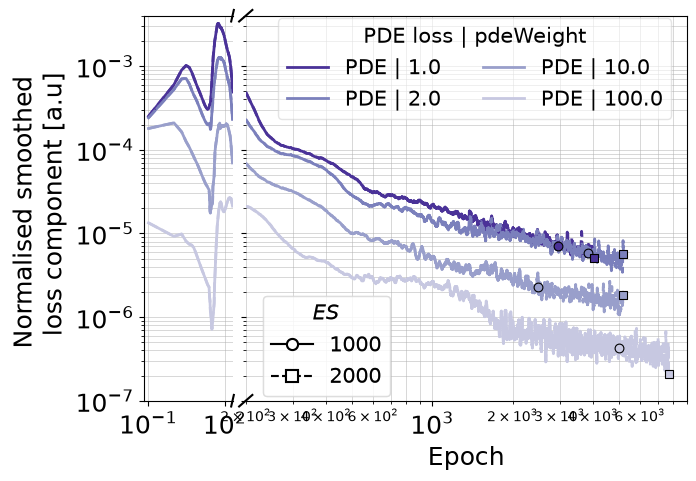

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS1/plot_e.png


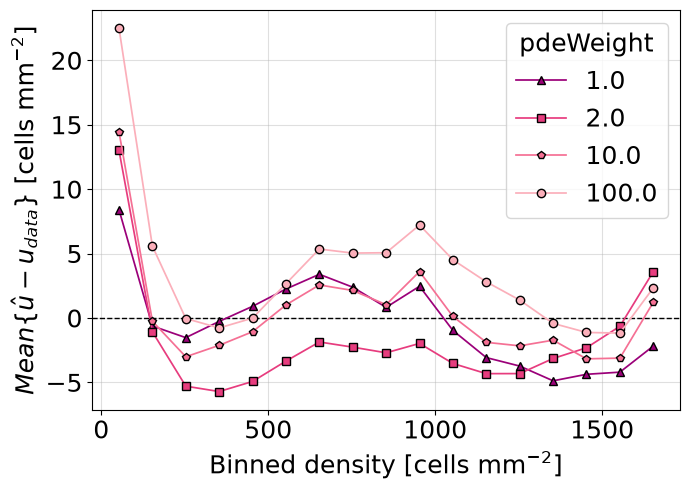

((None, None, None),
 (None, None),
 (<Figure size 700x500 with 1 Axes>,
  <Axes: xlabel='Binned density [cells mm$^{-2}]$', ylabel='$Mean \\{\\hat{u} - u_{data}\\}$ [cells mm$^{-2}]$'>),
 (None, None, None),
 (None, None))

In [8]:
combined_component_specs = [
        {
        "component_name": "data",
        "plot_name": "plot_c.png",
        "colors": component_pink_colors,
        "legend_title": "Data loss | pdeWeight",
        "legend_loc": (0.05, 1.02),
        "legend_loc_upd": (0.8, 0.75),
        "y_lim": (3e-5, 1e-1),
    },
        
    {
        "component_name": "pde",
        "plot_name": "plot_d.png",
        "colors": component_purple_colors,
        "legend_title": "PDE loss | pdeWeight",
        "legend_loc": (0.05, 1.02),
        "legend_loc_upd": (0.35, 0.3),
        "y_lim": (1e-7, 4e-3),
    }
]

COMPONENT_SEED = 0
COMPONENT_SMOOTHING_WINDOW = 25

component_grid_plot_settings = {
    "name": str(figure_s1_dir / "row2"),
    "fill": True,
    "line_width": 2,
    "color_indices": component_color_indices,
    "marker_indices": component_marker_indices,
    "es_entries": pde_weight_es_entries,
    "xaxis": X_AXIS,
    "fontsizes": AXIS_FONTSIZES,
    "figsize": FIGSIZE,
    "ylabel": "Normalised smoothed \n loss component [a.u]",
    "legend": {
        "panel": 2,
        "fontsize": 15,
        "ncols": 2,
        "title": "Loss",
        "marker_title": "$ES$",
        "edgecolor": "lightgray",
    },
}

# Plot (c), (d) of figure S1
for component_spec in combined_component_specs:
    component_plot_settings = {
        **component_grid_plot_settings,
        "name": str(figure_s1_dir / component_spec["plot_name"]),
        "y_lim": component_spec["y_lim"],
        "legend": {
            **component_grid_plot_settings["legend"],
            "title": component_spec["legend_title"],
            "loc": component_spec["legend_loc"],
            "loc_upd": component_spec["legend_loc_upd"],
        },
    }

    plot_smoothed_loss_components_seed_broken_x_log_lst(
        models_dics_list=component_models_flat,
        plot_settings=component_plot_settings,
        legend_labels=component_group_labels,
        legend_label_title=None,
        seed=COMPONENT_SEED,
        smoothing_window=COMPONENT_SMOOTHING_WINDOW,
        components={
            component_spec["component_name"]: {
                "colors": component_spec["colors"],
                "palette": tuple(component_spec["colors"]),
            },
        },
        separate_plots_by_group=False,
        print_best_epoch_losses=True,
        normalize_by_loss_weights=True,
    )
    

density_error_models_by_pde_weight = {
    str(weight): s11_models_by_pde_weight[weight][SELECTED_ES][SELECTED_D_WIDTH][SELECTED_U_WIDTH]
    for weight in PDE_WEIGHTS
}

density_error_data_by_pde_weight = {
    str(weight): data_obj
    for weight in PDE_WEIGHTS
}

density_error_colors = {
    str(weight): pde_weight_pink_colors[i]
    for i, weight in enumerate(PDE_WEIGHTS)
}

density_error_save_names = {
    "signed": str(figure_s1_dir / "plot_e.png")
}

# Plot (e) of figure S1
plot_binned_density_error_agg_groups_multi_data_mean(
    modelWrappers_by_group=density_error_models_by_pde_weight,
    dataobjs_by_group=density_error_data_by_pde_weight,
    device="cpu",
    K=REALISTIC_CARRYING_CAPACITY,
    bin_width=100.0,
    bin_reference="clean",
    error_units="abs",
    binned_error_logy=False,
    fig_size=FIGSIZE,
    group_colors=density_error_colors,
    legend_fontsize=LEGEND_SIZE,
    save_names=density_error_save_names,
    legend_title="pdeWeight",
    plot_histograms=True,
    histogram_split="trainval",
    axis_fontsizes=AXIS_FONTSIZES,
       grid=True,
       fill=False,
      seed_index=2,
      square_error=False,
)



## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
